In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point, LineString
from opentnsim import graph

from pathlib import Path
import pickle
import folium
import pyproj

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr
from opentnsim.core import Identifiable, Movable 
from opentnsim.core.vessel_properties import VesselProperties
from opentnsim.graph import HasMultiDiGraph, plot_graph_folium
from opentnsim.vessel_traffic_service import VesselTrafficService
from opentnsim.port.mixins.port import IsPort, HasPortAccess
from opentnsim.port.mixins.terminal import IsTerminal, HasTerminal
from opentnsim.port.mixins.berth import IsJetty, IsQuay
from opentnsim.port.mixins.anchorage_area import IsAnchorage, PassesAnchorage
from opentnsim.port.mixins.tidal_accessibility import HasDraughtRestrictions
from opentnsim.port.tidal_window_constructor import vessel_specifications, \
                                                    vertical_tidal_window_specifications, \
                                                    vertical_tidal_window_input, \
                                                    horizontal_tidal_window_specifications, \
                                                    horizontal_tidal_window_method, \
                                                    horizontal_tidal_window_input, \
                                                    tidal_period, \
                                                    accessibility, \
                                                    NetworkProperties
from opentnsim.port.rule_constructor import vessel_characteristics, vessel_direction, vessel_type
from opentnsim.port.visualizations import plot_vessels_over_route
from opentnsim.port.mixins.rules import IsRule, MathematicalOperator, VesselParameter, WaterwayParameter, ComparisonExpr, AggregateExpr, Operator
from opentnsim.port.mixins.waterway import IsWaterway, PassesWaterway

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart

# package(s) for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
data_dir = Path('data/Port_accessibility/')

#### Define input
vessel

In [4]:
vessel_length = 300
vessel_beam = 40
vessel_draught = 10.5
vessel_speed = 4.5 #m/s
vessel_loading_time = 6 #hours

infrastructure

In [5]:
waterway_length = 25000 #meters
waterway_width = 50
waterway_depth = 15 #meters (NGD: nautical guaranteed depth = MBL: maintained bed level)

harbour_basin_depth = 16.5
anchorage_area_depth = 17

tide

In [6]:
tidal_period = 12.5 #hours
tidal_range_sea = 2.0 #meters
tidal_propagation_speed = np.sqrt(9.81*waterway_depth) #meters per second (np.sqrt(grav_acc*waterway_depth)), grav_acc=9.81
tidal_amplication = 0.8 #amplification factor

tidal restrictions

In [7]:
#percentage of the draught as UKC (10% of draught is common)
ukc_percentage_sea = 10.0 #% of draught 
ukc_percentage_canal = 10.0 #% of draught

#static value as UKC (0.5 m is common, but not in combination with ukc_percentage)
ukc_static_sea = 0.0 #meters
ukc_static_canal = 0.0 #meters

#freshwater allowance as percentage of draught as additional UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage common)
fwa_sea = 0.0 #% of draught
fwa_canal = 0.0 #% of draught

#### 0. Create environment

In [8]:
# set simulation time
simulation_start = datetime.datetime(2019, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2019, 1, 8, 0, 0, 0)

# create time series aligned with simulation time
timestep = pd.Timedelta(minutes=5)
time_series = pd.date_range(simulation_start,simulation_stop,freq=timestep)

env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

In [9]:
data_dir = Path('data/Port_accessibility/')

#### 1. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a single edge of 100 km exactly.

In [10]:
filename = 'traffic_network_RdlP.pickle'
with open(data_dir / filename, 'rb') as f:
    graph = pickle.load(f)
    
filename = 'anchorage_areas_RdlP.pickle'
anchorage_areas = pd.read_pickle(data_dir / filename)

filename = 'berths_RdlP.pickle'
berths = pd.read_pickle(data_dir / filename)

filename = 'turning_basins_RdlP.pickle'
turning_basins = pd.read_pickle(data_dir / filename)

In [11]:
from shapely.ops import transform
wgs84 = pyproj.CRS('EPSG:4326')
utm = pyproj.CRS('EPSG:5348')
project = pyproj.Transformer.from_crs(wgs84, utm, always_xy=True).transform

In [12]:
for edge in graph.edges:
    geometry_wgs = graph.edges[edge]['geometry']
    geometry_utm = transform(project, geometry_wgs)
    graph.edges[edge]['length_m'] = geometry_utm.length

In [13]:
m = plot_graph_folium(graph, longitude=-58.1, latitude=-34, zoom_start = 8, 
                      berths = berths, turning_basins = turning_basins, anchorage_areas = anchorage_areas)
m

In [14]:
env.graph = nx.DiGraph(graph)

#### 1a. Adding a Vessel Traffic Service (VTS)

In [15]:
# create empty hydrodynamic dataset
filename = 'hydrodynamic_data_RdlP.nc'
hydrodynamic_data = xr.open_dataset(data_dir / filename)

In [16]:
time_series = hydrodynamic_data.TIME.values
for index,node in enumerate(graph.nodes):
    MBL_station = xr.DataArray([10.36]*len(time_series),dims={'TIME':time_series},coords={'TIME':time_series,'STATION':node})
    if not index:
        MBL = MBL_station
    else:
        MBL = xr.concat([MBL,MBL_station],dim='STATION')

In [17]:
hydrodynamic_data['MBL'] = MBL

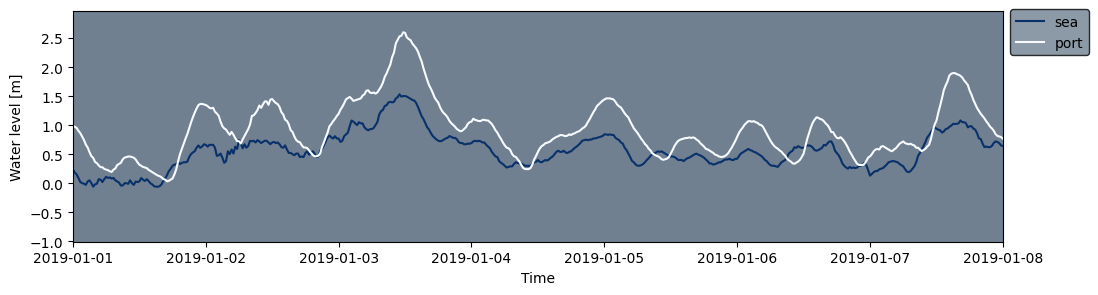

In [18]:
fig,ax = plt.subplots(figsize=[12,3])
ax.set_facecolor('slategrey')
cmap = plt.get_cmap('Blues_r')
ax.plot(hydrodynamic_data.TIME.values,hydrodynamic_data['Water level'].sel({'STATION':'Zona De Alijo'}).values,color=cmap(0),label='sea')
ax.plot(hydrodynamic_data.TIME.values,hydrodynamic_data['Water level'].sel({'STATION':'Recalada Nuevo Puerto Buenos Aires'}).values,color=cmap(cmap.N),label='port')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xlabel('Time')
ax.set_ylabel('Water level [m]')
ax.set_xlim(pd.Timestamp('2019-01-01'),pd.Timestamp('2019-01-08'))
ax.legend(loc='upper right',frameon=True,bbox_to_anchor=[1.1,1.0375],facecolor='slategray',edgecolor='k');

In [19]:
vessel_traffic_service = VesselTrafficService(hydrodynamic_data = hydrodynamic_data)
env.vessel_traffic_service = vessel_traffic_service

In [20]:
ukc_p = np.zeros(len(graph.nodes)) #percentage of the UKC (10% of draught is common)
ukc_s = np.zeros(len(graph.nodes))#static value of the UKC
fwa = np.zeros(len(graph.nodes)) #freshwater allowance as percentage of UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage)

network_properties = NetworkProperties()
for index,node in enumerate(env.graph.nodes):
    env.graph.nodes[node]['Vertical tidal restriction'] = {}
    vertical_tidal_window_inputs = []

    vessel_specification = vessel_specifications({vessel_characteristics.min_ge_Draught: 0.0},'x',vessel_direction.inbound)
    window_specification = vertical_tidal_window_specifications(ukc_s = ukc_s[index],
                                                                ukc_p = ukc_p[index],
                                                                fwa = fwa[index],)
    
    vertical_tidal_window_inputs.append(vertical_tidal_window_input(vessel_specifications = vessel_specification,
                                                                    window_specifications = window_specification))

    network_properties.append_vertical_tidal_restriction_to_network(env.graph,node,vertical_tidal_window_inputs)

#### 1b. Adding Port Infrastructure

In [21]:
port = IsPort(env=env, name = "Dock Sud", port_entry_nodes=['Zona De Alijo'])

In [22]:
anchorage1 = IsAnchorage(env=env, capacity=20, name = 'Zona Recalada', node = 'Zona De Alijo', depth = anchorage_area_depth, 
                        geometry=env.graph.nodes['Zona De Alijo']['geometry'], port = port)

anchorage2 = IsAnchorage(env=env, capacity=20, name = 'Zona de Fondeo y Espera Banco Chico', node = 'KM_99', depth = anchorage_area_depth, 
                        geometry=env.graph.nodes['KM_99']['geometry'], port = port)

anchorage3 = IsAnchorage(env=env, capacity=20, name = 'Zona de Fondeo y Espera de Practicaje Oeste 1', node = 'Rada La Plata - Zona Comun', depth = anchorage_area_depth, 
                        geometry=env.graph.nodes['Rada La Plata - Zona Comun']['geometry'], port = port)

anchorage4 = IsAnchorage(env=env, capacity=20, name = 'Zona de Fondeo y Espera de Practicaje Oeste 2', node = 'Rada La Plata - Zona Comun', depth = anchorage_area_depth, 
                        geometry=env.graph.nodes['Rada La Plata - Zona Comun']['geometry'], port = port)

anchorage5 = IsAnchorage(env=env, capacity=20, name = 'Zona de Fondeo y Espera de Practicaje Este 1', node = 'Rada La Plata - Zona Comun', depth = anchorage_area_depth, 
                        geometry=env.graph.nodes['Rada La Plata - Zona Comun']['geometry'], port = port)

anchorage6 = IsAnchorage(env=env, capacity=20, name = 'Zona de Fondeo y Espera de Practicaje Este 2', node = 'Rada La Plata - Zona Comun', depth = anchorage_area_depth, 
                        geometry=env.graph.nodes['Rada La Plata - Zona Comun']['geometry'], port = port)

In [23]:
quay1 = IsQuay(env=env, length=510, depth=9.75, name='1',node='Canal de Acceso Puerto Buenos Aires Sur')
quay2 = IsQuay(env=env, length=340, depth=9.75, name='2',node='Canal de Acceso Puerto Buenos Aires Sur')
quay3 = IsQuay(env=env, length=360, depth=9.75, name='3',node='Canal de Acceso Puerto Buenos Aires Sur')

berths = [quay1,quay2,quay3]

terminal = IsTerminal(env=env, name = 'Contenadores', berths=berths, port = port)

In [24]:
waterway1 = IsWaterway(env=env,
                      name='Canal Punta Indio (1)',
                      node_start='Punta Indio KM_121',
                      node_stop='Punta Indio KM_210',
                      width=70.)
waterway2 = IsWaterway(env=env,
                      name='Canal Punta Indio (2)',
                      node_start='Punta Indio KM_210',
                      node_stop='Zona De Alijo',
                      width=70.)

#Sum of beams should be smaller than width of waterway
traffic_rule = AggregateExpr(VesselParameter.beam(), MathematicalOperator.smaller_than(), WaterwayParameter.width())
waterway.add_traffic_rule(traffic_rule)

NameError: name 'waterway' is not defined

In [ ]:
rule1_punta_indio_1 = 'vessel.L > 0 with vessel.L > vessel.type == A or vessel.type == B'
rule2_punta_indio_1 = 'vessel.type == A with vessel.type == A'
rule3_punta_indio_1 = 'vessel.L > 340 or vessel.B > 49 with vessel.L > vessel.type == A or vessel.type == B'

rule1_punta_indio_2 = 'vessel.L > 0 with vessel.L > vessel.type == A'
rule2_punta_indio_2 = 'vessel.type == A with vessel.type == A'
rule3_punta_indio_2 = 'vessel.L > 340 or vessel.B > 49 with vessel.L > vessel.type == A'

#### 2. Create agents

In [ ]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (PassesWaterway,
     HasPortAccess,
     HasTerminal,
     PassesAnchorage,
     HasDraughtRestrictions,
     HasMultiDiGraph,
     Identifiable, # allows to give the object a name and a random ID,
     Movable,      # allows the object to move, with a fixed speed, while logging this activity
     VesselProperties,
    ), 
    {}
)

In [ ]:
def mission(env, vessel, arrival_time = simulation_start):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    if arrival_time < simulation_start:
        raise ValueError("The vessel's arrival time at the port should be later that the simulation start time")
    else:
        delay = (arrival_time - simulation_start).total_seconds()
        yield vessel.env.timeout(delay)
    yield from vessel.move()

In [ ]:
def create_vessel(name, route, next_destination, 
                  vessel_speed = 6, berthing_time = 15, loading_time = 12, deberthing_time = 5, 
                  vessel_length = vessel_length, vessel_beam = vessel_beam, vessel_draught = vessel_draught):
    data_vessel = {"env": env,                                        # needed for simpy simulation
                   "name": name,                                      # required by Identifiable
                   "geometry": env.graph.nodes[route[0]]['geometry'], # required by Locatable
                   "route": route,                                    # required by Routeable
                   "v": vessel_speed,                                 # required by Movable, 1 m/s to check if the distance is covered in the expected time
                   "bound": 'inbound',
                   "terminal": terminal,
                   "berthing_time":berthing_time, #minutes
                   "loading_time": loading_time, #hours
                   "deberthing_time":deberthing_time, #minutes
                   "next_destination":next_destination,
                   "type":"tanker",
                   "L":vessel_length,
                   "B":vessel_beam,
                   "T":vessel_draught,
                   }
    vessel = Vessel(**data_vessel)
    return vessel

In [ ]:
# create vessel from a dict 
route = nx.dijkstra_path(env.graph, "Zona De Alijo", "Canal de Acceso Puerto Buenos Aires Sur")
vessel_1 = create_vessel("vessel_1", route, "Zona De Alijo")

# start the simulation
vessel_1.mission = env.process(mission(env, vessel_1))

In [ ]:
plt.plot(hydrodynamic_data.sel({'STATION':'Zona De Alijo'})['Water level'].values)

#### 3. Run simulation

In [ ]:
env.run()

#### 4. Inspect output

##### Logbook
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [ ]:
# load the logbook data into a dataframe
for vessel in env.vessels:
    df = pd.DataFrame.from_dict(vessel.logbook)
    
    print("'{}' logbook data:".format(vessel.name))  
    print('')
    
    display(df)
    
    if not df.empty:
        trip_distance = opentnsim.graph.calculate_distance_along_path(graph, vessel.route)
        trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
        print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
        print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
        print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
    else:
        print("The port was not accessible for vessel")
    print('')
    print('')

##### Vessel trajectories
We can plot the vessel trajectories

In [ ]:
# fig = plot_vessels_over_route(env,'Canal de Acceso Puerto Buenos Aires Sur','Zona De Alijo',env.vessels,ddistance=10000)
# fig

In [ ]:
trip_index = 0
fig = vessel.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig

###### Vessel processes
And the Gantt chart

In [ ]:
df_eventtable = logbook2eventtable([vessel_1])
generate_vessel_gantt_chart(df_eventtable)